<a href="https://www.kaggle.com/code/lalit7881/coffee-shop-transactions-revenue-eda?scriptVersionId=311672541" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nohahasan007/coffee-sales-dataset/Coffe_sales.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/nohahasan007/coffee-sales-dataset/Coffe_sales.csv")

In [3]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [4]:
df.tail()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000
3546,18,card,35.76,Latte,Night,Sun,Mar,7,3,2025-03-23,18:11:38.635000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


In [6]:
df.describe()

,hour_of_day,money,Weekdaysort,Monthsort
count,3547.000000,3547.000000,3547.000000,3547.000000
mean,14.185791,31.645216,3.845785,6.453905
std,4.234010,4.877754,1.971501,3.500754
min,6.000000,18.120000,1.000000,1.000000
25%,10.000000,27.920000,2.000000,3.000000
50%,14.000000,32.820000,4.000000,7.000000
75%,18.000000,35.760000,6.000000,10.000000
max,22.000000,38.700000,7.000000,12.000000


In [7]:
df.isnull().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

hour_of_day      int64
cash_type       object
money          float64
coffee_name     object
Time_of_Day     object
Weekday         object
Month_name      object
Weekdaysort      int64
Monthsort        int64
Date            object
Time            object
dtype: object

In [10]:
df.shape

(3547, 11)

In [11]:
df.columns

Index(['hour_of_day', 'cash_type', 'money', 'coffee_name', 'Time_of_Day',
       'Weekday', 'Month_name', 'Weekdaysort', 'Monthsort', 'Date', 'Time'],
      dtype='object')

In [12]:
df.nunique()

hour_of_day      17
cash_type         1
money            13
coffee_name       8
Time_of_Day       3
Weekday           7
Month_name       12
Weekdaysort       7
Monthsort        12
Date            381
Time           3547
dtype: int64

## EDA

In [13]:
print(df.shape)
print(df.info())
print(df.describe())

(3547, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB
None
       hour_of_day        money  Weekdaysort    Monthsort
count  3547.000000  3547.000000  3547.000000  3547.000000
mean     14.185791    31.645216     3.845785     6.453905
std       4.234010     4.877754     1.971501     3.500754
min       6.000000    18.120000    

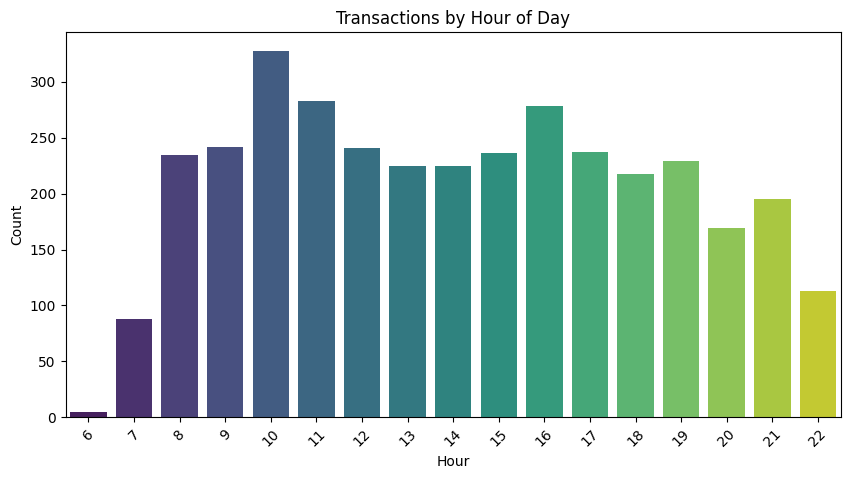

In [14]:
plt.figure(figsize=(10,5))
sns.countplot(x='hour_of_day', data=df, palette='viridis')
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

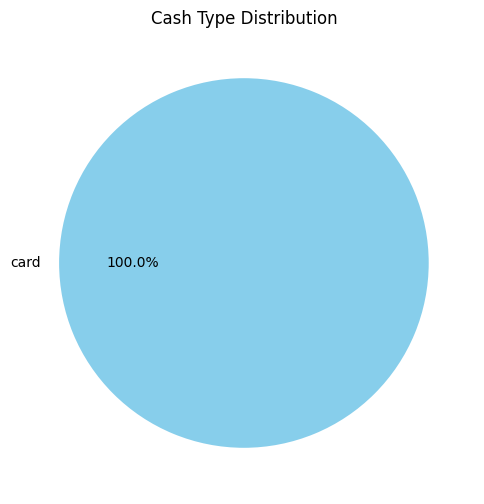

In [15]:
plt.figure(figsize=(6,6))
df['cash_type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%',
    colors=['skyblue','orange','green']
)
plt.title("Cash Type Distribution")
plt.ylabel("")
plt.show()

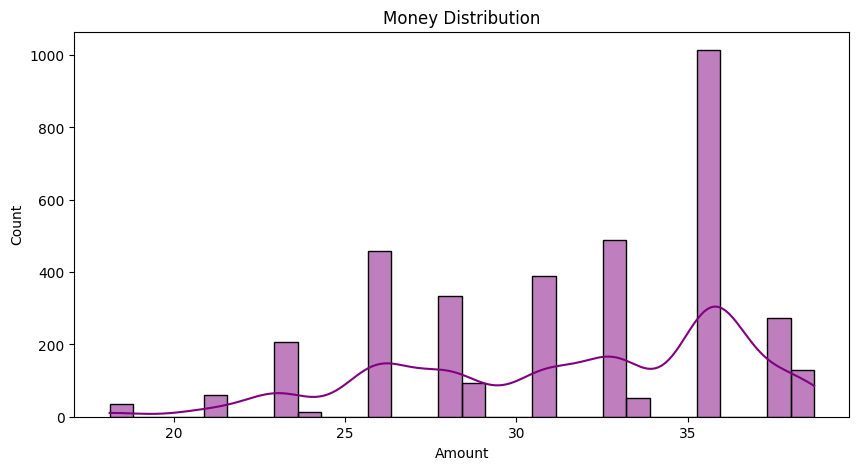

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['money'], bins=30, kde=True, color='purple')
plt.title("Money Distribution")
plt.xlabel("Amount")
plt.show()

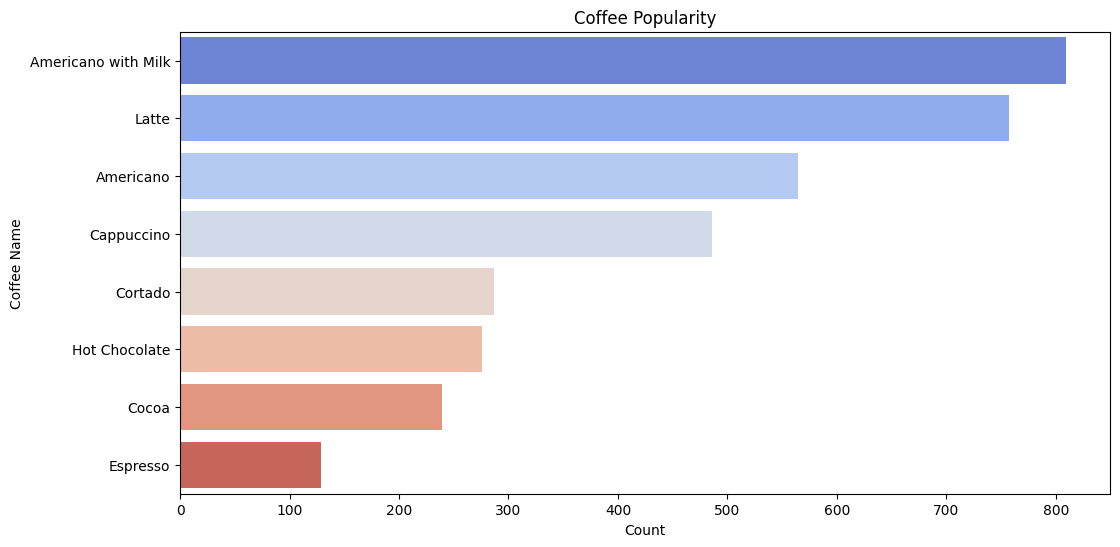

In [17]:
plt.figure(figsize=(12,6))
sns.countplot(
    y='coffee_name',
    data=df,
    order=df['coffee_name'].value_counts().index,
    palette='coolwarm'
)
plt.title("Coffee Popularity")
plt.xlabel("Count")
plt.ylabel("Coffee Name")
plt.show()

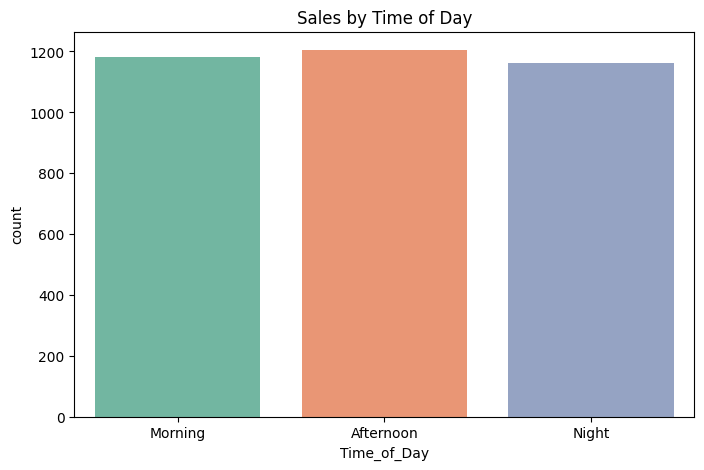

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='Time_of_Day', data=df, palette='Set2')
plt.title("Sales by Time of Day")
plt.show()

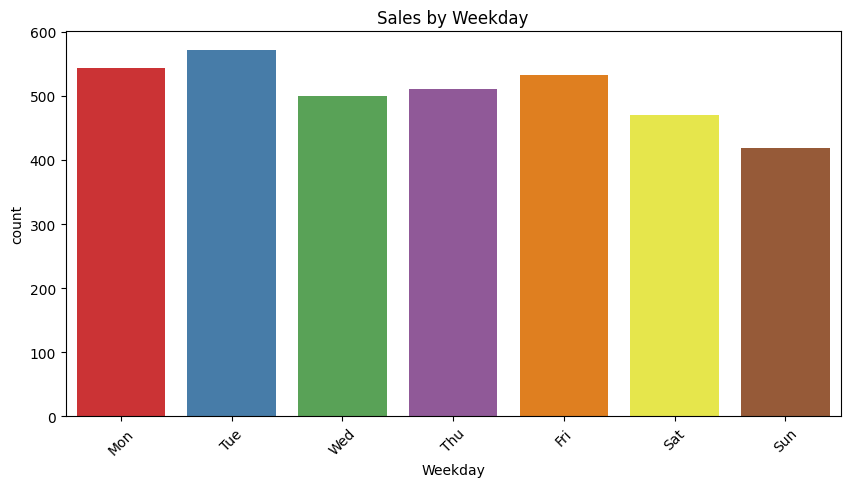

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Weekday',
    data=df,
    order=df.sort_values('Weekdaysort')['Weekday'].unique(),
    palette='Set1'
)
plt.title("Sales by Weekday")
plt.xticks(rotation=45)
plt.show()

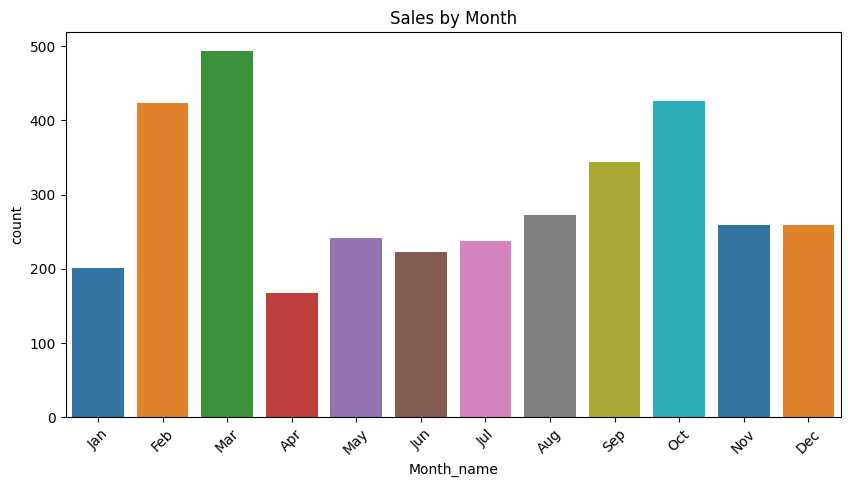

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='Month_name',
    data=df,
    order=df.sort_values('Monthsort')['Month_name'].unique(),
    palette='tab10'
)
plt.title("Sales by Month")
plt.xticks(rotation=45)
plt.show()

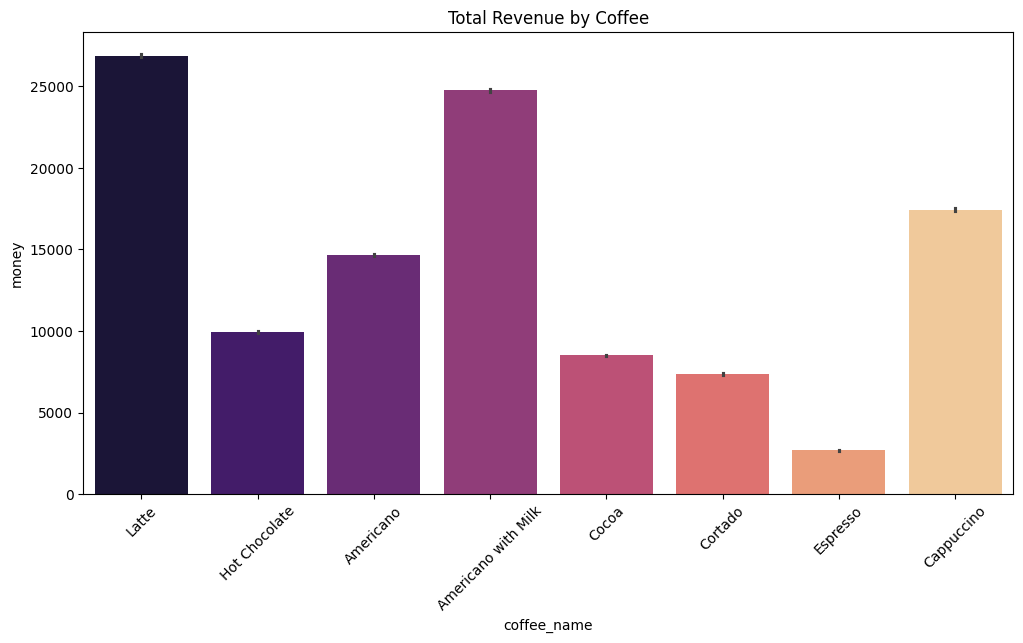

In [21]:
plt.figure(figsize=(12,6))
sns.barplot(
    x='coffee_name',
    y='money',
    data=df,
    estimator=sum,
    palette='magma'
)
plt.title("Total Revenue by Coffee")
plt.xticks(rotation=45)
plt.show()

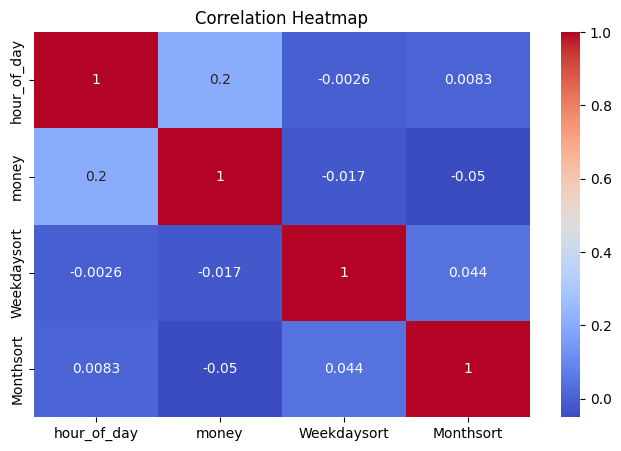

In [22]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[['hour_of_day','money','Weekdaysort','Monthsort']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

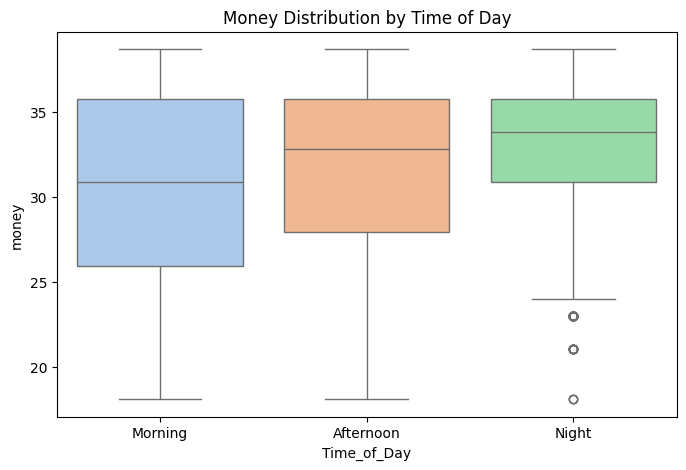

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Time_of_Day',
    y='money',
    data=df,
    palette='pastel'
)
plt.title("Money Distribution by Time of Day")
plt.show()

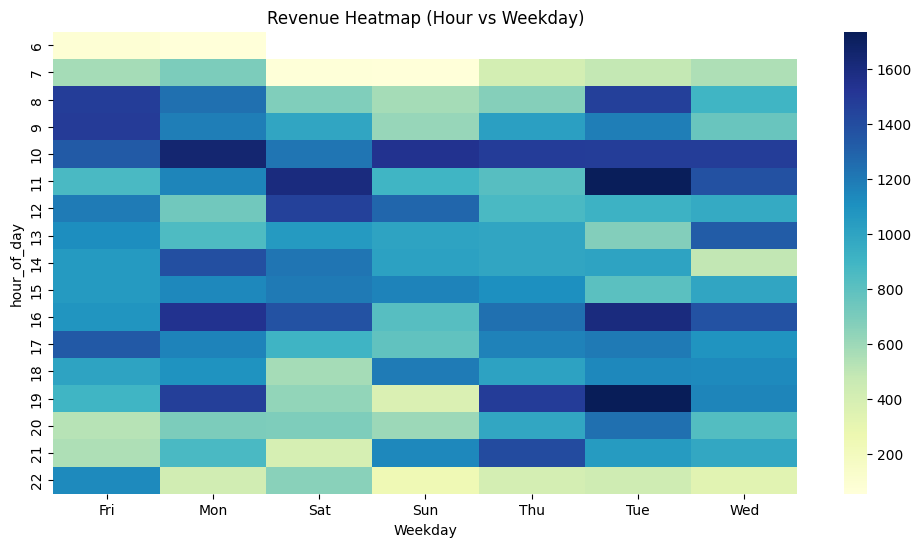

In [24]:
pivot = df.pivot_table(
    values='money',
    index='hour_of_day',
    columns='Weekday',
    aggfunc='sum'
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='YlGnBu')
plt.title("Revenue Heatmap (Hour vs Weekday)")
plt.show()

## Feature engineering

Before Encoding:
coffee_name
Americano with Milk    647
Latte                  605
Americano              451
Cappuccino             389
Cortado                230
Hot Chocolate          221
Cocoa                  191
Espresso               103
Name: count, dtype: int64

===== Logistic Regression =====
Accuracy: 0.5859154929577465
              precision    recall  f1-score   support

           0       0.64      0.79      0.71       113
           1       0.76      0.98      0.85       162
           2       0.47      0.19      0.27        97
           3       0.00      0.00      0.00        48
           4       0.42      0.19      0.27        57
           5       1.00      0.62      0.76        26
           6       0.00      0.00      0.00        55
           7       0.44      0.82      0.57       152

    accuracy                           0.59       710
   macro avg       0.47      0.45      0.43       710
weighted avg       0.50      0.59      0.51       710



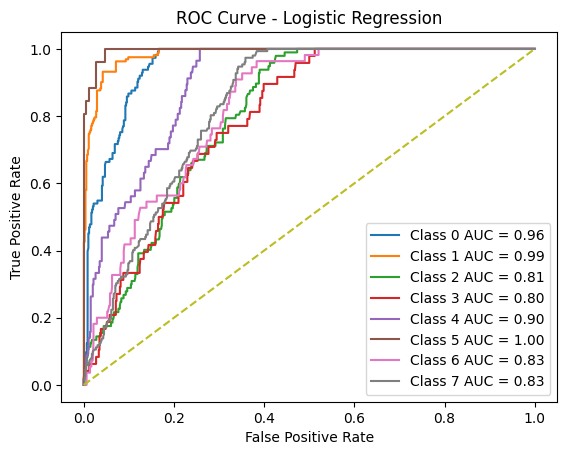


===== Random Forest =====
Accuracy: 0.6323943661971831
              precision    recall  f1-score   support

           0       0.75      0.77      0.76       113
           1       0.98      0.98      0.98       162
           2       0.38      0.36      0.37        97
           3       0.27      0.29      0.28        48
           4       0.56      0.56      0.56        57
           5       1.00      0.88      0.94        26
           6       0.32      0.31      0.31        55
           7       0.53      0.54      0.53       152

    accuracy                           0.63       710
   macro avg       0.60      0.59      0.59       710
weighted avg       0.63      0.63      0.63       710



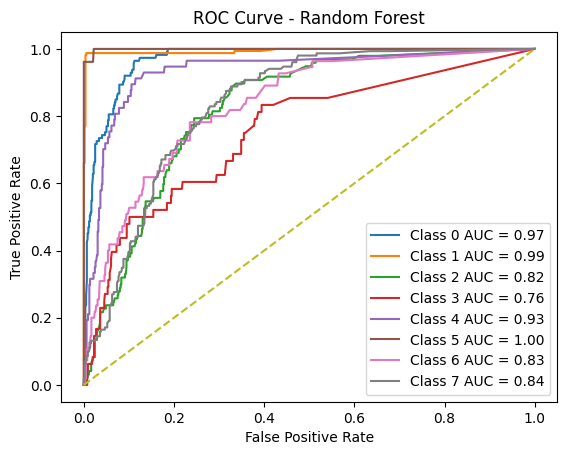


===== FINAL COMPARISON =====
Logistic Regression Accuracy: 0.5859154929577465
Random Forest Accuracy: 0.6323943661971831


In [25]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc



# ==============================
# 2. COPY DATA
# ==============================
data = df.copy()


# ==============================
# 3. SELECT TARGET
# ==============================
# IMPORTANT: use a column with multiple classes
target = 'coffee_name'   # safer than cash_type

X = data.drop(columns=[target, 'Date', 'Time'], errors='ignore')
y = data[target]


# ==============================
# 4. TRAIN TEST SPLIT (NO LEAKAGE)
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ==============================
# 5. CHECK TARGET DISTRIBUTION
# ==============================
print("Before Encoding:")
print(y_train.value_counts())


# ==============================
# 6. LABEL ENCODING (FEATURES)
# ==============================
le_dict = {}

for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    
    le_dict[col] = le


# ==============================
# 7. ENCODE TARGET
# ==============================
target_le = LabelEncoder()

y_train = target_le.fit_transform(y_train)
y_test = target_le.transform(y_test)


# ==============================
# 8. SAFETY CHECK
# ==============================
if len(np.unique(y_train)) < 2:
    raise ValueError("❌ Only one class found in target. Choose different target.")


# ==============================
# 9. FEATURE SCALING
# ==============================
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==============================
# 🚀 MODEL 1: LOGISTIC REGRESSION
# ==============================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)

print("\n===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


# ==============================
# ROC CURVE (MULTICLASS SAFE)
# ==============================
from sklearn.preprocessing import label_binarize

n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} AUC = {roc_auc[i]:.2f}')

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


# ==============================
# 🚀 MODEL 2: RANDOM FOREST
# ==============================
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)

print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# ==============================
# ROC CURVE - RANDOM FOREST
# ==============================
fpr_rf = dict()
tpr_rf = dict()
roc_auc_rf = dict()

for i in range(n_classes):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

plt.figure()
for i in range(n_classes):
    plt.plot(fpr_rf[i], tpr_rf[i], label=f'Class {i} AUC = {roc_auc_rf[i]:.2f}')

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()


# ==============================
# 📊 FINAL COMPARISON
# ==============================
print("\n===== FINAL COMPARISON =====")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

## Thank you...pls upvote!!!!!!!!!!